In [2]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

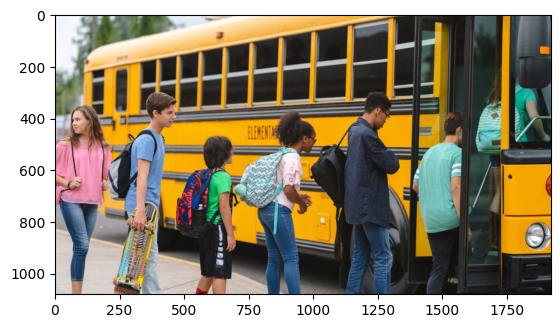

In [161]:
image = cv2.imread("../dataset/Images/image3.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [179]:
model = YOLO("yolo11n.pt")

In [38]:
results = model(image, conf=0.4, iou=0.9)


0: 448x640 13 persons, 1 bus, 3 traffic lights, 2 backpacks, 1 handbag, 65.9ms
Speed: 2.7ms preprocess, 65.9ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


In [39]:
for res in results:
    res.show() 

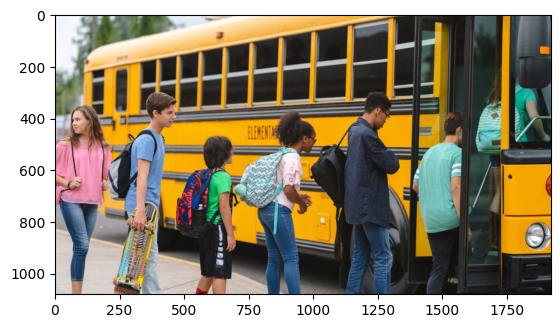

In [42]:
image = cv2.imread("../dataset/Images/image3.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

COCO Dataset Classes
https://gist.github.com/SrikarNamburu/0945de8f9a8714ec245dde3443e9d487

🔹 IoU (Intersection over Union) কী?

IoU = (দুইটা bounding box-এর overlapping এলাকা) ÷ (তাদের union এলাকা)

IoU মান 0 থেকে 1 এর মধ্যে হয়।

IoU = 0.8 → অনেক বেশি overlap।

IoU = 0.2 → কম overlap।

🔹 মানগুলো

"cpu" → কেবল CPU ব্যবহার করবে

"0" → প্রথম GPU (CUDA:0) ব্যবহার করবে

"1" → দ্বিতীয় GPU (CUDA:1) ব্যবহার করবে

"0,1" → একাধিক GPU (Multi-GPU training)

None → ডিফল্ট অটো-সিলেক্ট (যদি GPU থাকে সেটাই, না থাকলে CPU)

# YOLOv8 training example
- yolo detect train data=coco.yaml model=yolov8n.pt epochs=50 batch=16
- 👉 এখানে batch=16 মানে প্রতি iteration-এ 16টা image একসাথে GPU-তে যাবে।

In [85]:
results = model(image, conf=0.4, iou=0.7, imgsz=640, classes=[5], device="cpu")
for res in results:
    res.show() 


0: 384x640 1 bus, 104.3ms
Speed: 2.6ms preprocess, 104.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)


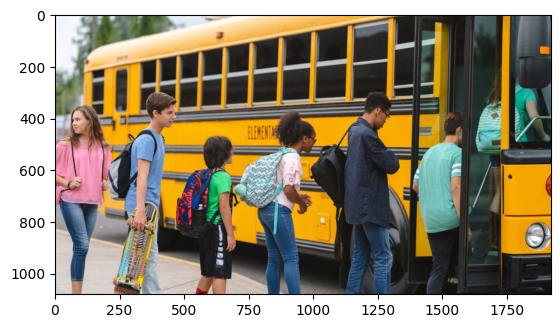

In [76]:
image2 = cv2.imread("../dataset/Images/image3.png")
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
plt.imshow(image2)

In [169]:
results2 = model(image2, conf=0.25, iou=0.9, max_det=2) # max detected 2 object 
for res in results2:
    res.show() 


0: 384x640 2 persons, 56.4ms
Speed: 2.4ms preprocess, 56.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


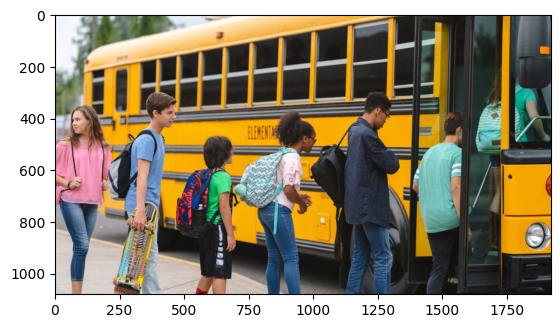

In [86]:
image2 = cv2.imread("../dataset/Images/image3.png")
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
plt.imshow(image2)


In [141]:
results2 = model(image2, conf=0.25, iou=0.7)
for res in results2:
    res.show()  


0: 384x640 6 persons, 1 bus, 3 backpacks, 53.6ms
Speed: 2.0ms preprocess, 53.6ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


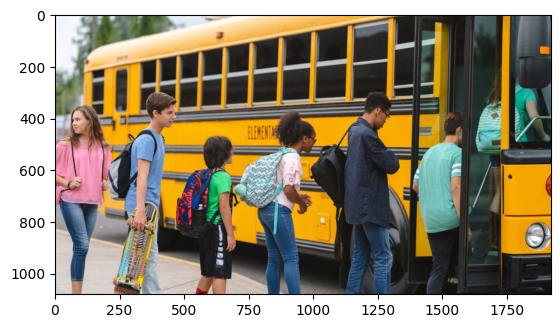

In [191]:
image = cv2.imread("../dataset/Images/image3.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [3]:
model = YOLO("yolo11n.pt")

In [4]:
cocoClassNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
                  "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog",
                  "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
                  "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite",
                  "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle",
                  "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
                  "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
                  "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
                  "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
                  "teddy bear", "hair drier", "toothbrush"]

In [5]:
import math


0: 384x640 6 persons, 1 bus, 3 backpacks, 57.2ms
Speed: 2.1ms preprocess, 57.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


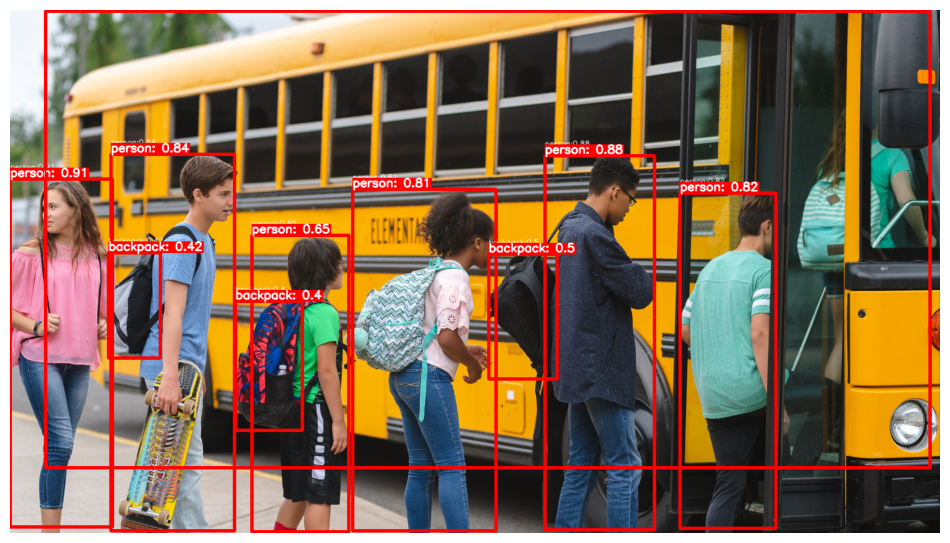

In [198]:
results2 = model(image2, conf=0.25, iou=0.7)

# Font settings
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.8   # ভালো সাইজ
thickness = 2      # টেক্সট মোটা
box_thickness = 2  # বক্স মোটা

for res in results2:
    boxes = res.boxes  
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        # draw rectangle bounding box
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), box_thickness)

        # Get classname
        classNameInt = int(box.cls[0])
        className = cocoClassNames[classNameInt]

        # Get conf score
        conf = math.ceil(box.conf[0] * 100) / 100
        label = f"{className}: {conf}"

        # --- Text background box ---
        (w, h), _ = cv2.getTextSize(label, font, font_scale, thickness)
        cv2.rectangle(image, (x1, y1 - h - 5), (x1 + w, y1), (255, 0, 0), -1)

        # --- Put text on background ---
        cv2.putText(image, label, (x1, y1 - 5), font, font_scale, (255, 255, 255), thickness, lineType=cv2.LINE_AA)

# Show final result (convert BGR → RGB for matplotlib)
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.show()


## Video

In [34]:
video = cv2.VideoCapture("../dataset/Videos/video5.mp4")

In [35]:
if not video.isOpened():
    print("video file is not loaded")
else:
    print("video file is loaded")

video file is loaded


In [36]:
# Font settings
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.8  
thickness = 2    
box_thickness = 2 

while True:
    ret, frame = video.read()

    # if there is no frame the break
    if not ret:
        break
    
    # model
    results = model(frame, conf=0.25, iou=0.7)

    person_count = 0 

    for res in results:
        boxes = res.boxes  
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            # draw rectangle bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), box_thickness)

            # Get classname
            classNameInt = int(box.cls[0])
            className = cocoClassNames[classNameInt]

            if className == "person":
                person_count += 1

            # Get conf score
            conf = math.ceil(box.conf[0] * 100) / 100
            label = f"{className}: {conf}"

            # --- Text background box ---
            (w, h), _ = cv2.getTextSize(label, font, font_scale, thickness)
            cv2.rectangle(frame, (x1, y1 - h - 5), (x1 + w, y1), (255, 0, 0), -1)

            # --- Put text on background ---
            cv2.putText(frame, label, (x1, y1 - 5), font, font_scale, (255, 255, 255), thickness, lineType=cv2.LINE_AA)

    # Show total person count on the frame
    cv2.putText(frame, f"Preson: {person_count}", (20, 40), font, 1, (0, 255, 0), 2, cv2.LINE_AA)

    cv2.imshow("Video", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
 

video.release()
cv2.destroyAllWindows()

0: 384x640 10 persons, 10 bicycles, 1 handbag, 71.7ms
Speed: 4.3ms preprocess, 71.7ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 persons, 9 bicycles, 124.9ms
Speed: 10.7ms preprocess, 124.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 10 bicycles, 100.7ms
Speed: 1.6ms preprocess, 100.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 persons, 11 bicycles, 72.5ms
Speed: 3.5ms preprocess, 72.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 10 bicycles, 60.7ms
Speed: 1.7ms preprocess, 60.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 persons, 10 bicycles, 63.1ms
Speed: 1.8ms preprocess, 63.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 persons, 8 bicycles, 1 backpack, 65.4ms
Speed: 2.2ms preprocess, 65.4ms inference, 0.8ms postprocess per image at shape (1, 3